In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from imblearn.over_sampling import SMOTE

import joblib

import warnings
warnings.filterwarnings("ignore")

In [24]:
df = pd.read_csv("titanic.csv")

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df["survived"].value_counts())

features = df.drop(columns="survived")
target = df["survived"]

train_features, test_features, train_target, test_target = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

print("\nTraining set:", train_features.shape)
print("Testing set :", test_features.shape)

print("\nTraining class distribution:")
print(train_target.value_counts())

Dataset shape: (891, 15)

Target distribution:
survived
0    549
1    342
Name: count, dtype: int64

Training set: (712, 14)
Testing set : (179, 14)

Training class distribution:
survived
0    439
1    273
Name: count, dtype: int64


In [25]:
numeric_features = ["age", "fare", "sibsp", "parch"]

categorical_features = ["sex", "embarked"]


numeric_pipeline = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [26]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        random_state=42
    )
}

trained_models = {}

for name, estimator in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", estimator)
    ])

    pipeline.fit(train_features, train_target)

    trained_models[name] = pipeline

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


In [27]:
results = []

predictions = {}
probabilities = {}

for name, model in trained_models.items():

    prediction = model.predict(test_features)
    probability = model.predict_proba(test_features)[:, 1]

    predictions[name] = prediction
    probabilities[name] = probability

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(test_target, prediction),
        "Precision": precision_score(test_target, prediction),
        "Recall": recall_score(test_target, prediction),
        "F1 Score": f1_score(test_target, prediction),
        "ROC AUC": roc_auc_score(test_target, probability)
    })

classification_results = pd.DataFrame(results)

classification_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7989,0.7797,0.6667,0.7188,0.8194
1,Decision Tree,0.8101,0.7966,0.6812,0.7344,0.8309
2,Random Forest,0.7933,0.7667,0.6667,0.7132,0.8238


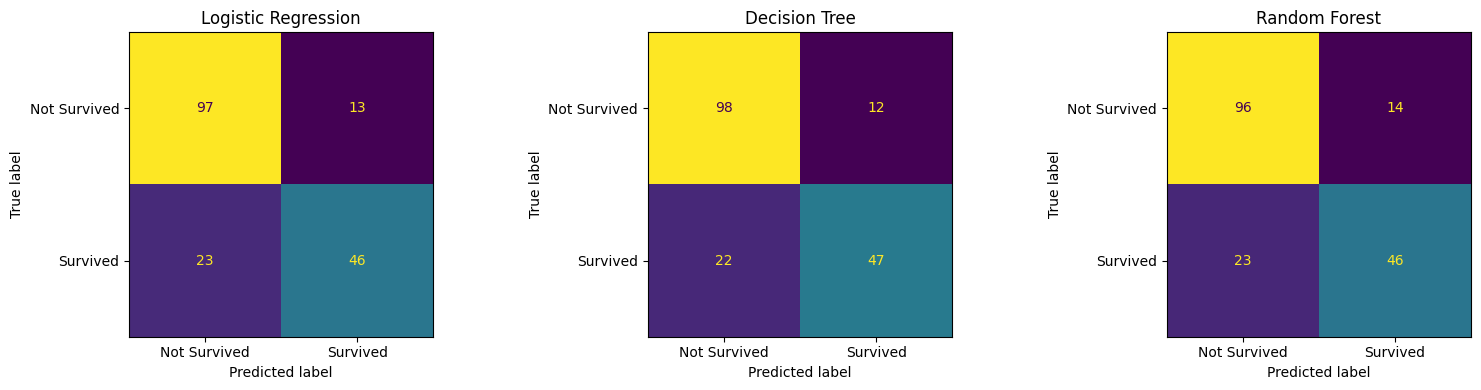

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, prediction) in zip(axes, predictions.items()):

    cm = confusion_matrix(test_target, prediction)

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Survived", "Survived"]
    )

    display.plot(ax=ax, colorbar=False)

    ax.set_title(name)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

In [29]:
rf_baseline = RandomForestClassifier(random_state=42, n_estimators=100)
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)

rf_balanced = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_balanced.fit(X_train, y_train)
y_pred_balanced = rf_balanced.predict(X_test)

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

rf_smote = RandomForestClassifier(random_state=42, n_estimators=100)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)

def compare_imbalance(y_test, y_pred_baseline, y_pred_balanced, y_pred_smote):
    for name, y_pred in [('Baseline', y_pred_baseline), ('class_weight=balanced', y_pred_balanced), ('SMOTE', y_pred_smote)]:
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        print(f"{name}: Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

compare_imbalance(y_test, y_pred_baseline, y_pred_balanced, y_pred_smote)

ValueError: could not convert string to float: 'male'

In [ ]:
rf_tuned = RandomForestClassifier(oob_score=True, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['auto', 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    rf_tuned, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best OOB score: {grid_search.best_score_:.4f}")

# Use the best estimator
best_rf = grid_search.best_estimator_


In [ ]:
tree_pipeline = trained_models["Decision Tree"]

tree_model = tree_pipeline.named_steps["model"]

transformed_features = tree_pipeline.named_steps[
    "preprocessing"
].get_feature_names_out()

In [ ]:
# Build comparison table
comparison_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Linear Regression (fare)'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf), None],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf), None],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_rf), None],
    'F1': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_rf), None],
    'AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1]), roc_auc_score(y_test, y_prob_rf), None],
    'MAE': [None, None, None, mae],
    'RMSE': [None, None, None, rmse],
    'R²': [None, None, None, r2],
    'Adjusted R²': [None, None, None, adj_r2],
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))


In [ ]:
# Save the complete pipeline (preprocessing + estimator)
joblib.dump(full_pipeline, 'pipeline.joblib')

# Verify reload
loaded_pipeline = joblib.load('pipeline.joblib')
print("\n=== Pipeline reload test ===")
# Predict on raw test data (should work without re-running preprocessing)
y_pred_reload = loaded_pipeline.predict(X_test)
print(f"Reloaded pipeline predictions match: {np.array_equal(y_pred_reload, y_pred_lr)}")

plt.figure(figsize=(22, 10))

plot_tree(
    tree_model,
    feature_names=transformed_features,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree - First Three Levels")
plt.tight_layout()

plt.savefig("decision_tree.png", dpi=150)
plt.show()

In [ ]:
plt.figure(figsize=(9, 6))

for name in trained_models:

    fpr, tpr, _ = roc_curve(
        test_target,
        probabilities[name]
    )

    score = roc_auc_score(
        test_target,
        probabilities[name]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()